# Building Damage Classification — MaxViT-Base
**Architecture:** MaxViT-Base (Multi-Axis Vision Transformer, IN-21k pretrained)  
**Why MaxViT:** Natively interleaves MBConv (CNN local features) + Window attention (local) + Grid attention (global) in every block. No separate fusion needed.  
**Pipeline:** Best-of-both from ConvNeXt & Swin-V2 — CB Focal Loss · Lion · EMA · MixUp + CutMix · 8-TTA · LLRD · Progressive resizing

In [2]:
!pip install lion-pytorch torch-ema timm albumentations rasterio -q

In [ ]:
# ── STEP 1: IMPORTS & CONFIG ──────────────────────────────────────────────────
import os, json, glob, time, cv2, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from rasterio.windows import Window
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import timm
from lion_pytorch import Lion
from torch_ema import ExponentialMovingAverage

warnings.filterwarnings('ignore')

# ── HARDWARE ──────────────────────────────────────────────────────────────────
device = torch.device("mps"  if torch.backends.mps.is_available()  else
                      "cuda" if torch.cuda.is_available()           else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR     = "../../Building_Damage_Project"
PROJECT_ROOT = os.path.join(BASE_DIR, "Final_Merge")
RAW_TRAIN    = os.path.join(BASE_DIR, "raw_data", "Train")
RAW_TEST     = os.path.join(BASE_DIR, "raw_data", "Test")
CHIP_DIR     = os.path.join(PROJECT_ROOT, "chip_data_maxvit")
os.makedirs(os.path.join(CHIP_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(CHIP_DIR, 'labels'), exist_ok=True)

# ── LABEL MAP ─────────────────────────────────────────────────────────────────
DAMAGE_MAP = {
    'no damage':    0, 'no-damage':    0, 'no_damage':    0,
    'minor damage': 1, 'minor-damage': 1, 'minor_damage': 1,
    'major damage': 2, 'major-damage': 2, 'major_damage': 2,
    'destroyed':    3
}
CLASS_NAMES = ['No Damage', 'Minor', 'Major', 'Destroyed']
NUM_CLASSES = 4

# ── HYPERPARAMETERS ───────────────────────────────────────────────────────────
# We extract 256px chips so training at both 224 and 256 works without
# re-running chip extraction.
CHIP_SIZE      = 256        # extraction window
IMG_SIZE       = 224        # MaxViT native training resolution
IMG_SIZE_FT    = 256        # progressive fine-tune resolution (last 10 epochs)
BATCH_SIZE     = 16         # MaxViT-Base is heavy; lower if OOM
GRAD_ACCUM     = 4          # effective batch = 64
EPOCHS         = 80
WARMUP_EPOCHS  = 5
LR_HEAD        = 5e-4       # Lion LR — head trains faster
LR_BACKBONE    = 5e-5       # LLRD: backbone gets 10x lower LR
WEIGHT_DECAY   = 0.05
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.4
CUTMIX_ALPHA   = 1.0
EMA_DECAY      = 0.9998
DROP_PATH_RATE = 0.2
PATIENCE       = 15

MODEL_SAVE = os.path.join(PROJECT_ROOT, 'best_model_maxvit.pth')
PLOT_SAVE  = os.path.join(PROJECT_ROOT, 'results_maxvit.png')

print("\nConfig:")
print(f"  Backbone       : maxvit_base_tf_224.in21k")
print(f"  Train res      : {IMG_SIZE}px  Fine-tune: {IMG_SIZE_FT}px")
print(f"  Effective batch: {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Epochs         : {EPOCHS}  Patience: {PATIENCE}")
print("Step 1 complete.")

Device: mps

Config:
  Backbone       : maxvit_base_tf_224.in21k
  Train res      : 224px  Fine-tune: 256px
  Effective batch: 64
  Epochs         : 80  Patience: 15
Step 1 complete.


In [4]:
# ── STEP 2: CHIP EXTRACTION ───────────────────────────────────────────────────
# Extracts 256x256 chips (larger than MaxViT's 224 native input) so we
# have room for progressive resizing without re-extraction.

def process_single_tif(tif_path, source_dir):
    filename   = os.path.basename(tif_path)
    prefix     = filename.replace('.tif', '').replace('_tif', '')
    base_json  = os.path.join(source_dir, f"{prefix}_json.json")
    align_json = os.path.join(source_dir, f"{prefix}_json_aligned.json")
    if not os.path.exists(base_json) or not os.path.exists(align_json):
        return 0, f"Missing JSON: {prefix}"
    chips_saved = 0
    try:
        with rasterio.open(tif_path) as src:
            with open(align_json) as f:
                align_data = json.load(f)
            s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
            s_y = np.mean([p[1][1] - p[0][1] for p in align_data])
            with open(base_json) as f:
                entries = json.load(f)
            for i, entry in enumerate(entries):
                raw_label = entry.get('label', 'no damage').lower().strip()
                label = DAMAGE_MAP.get(raw_label, -1)
                if label == -1:
                    continue
                px_coords = entry['pixels']
                avg_px_x  = np.mean([p['x'] for p in px_coords]) + s_x
                avg_px_y  = np.mean([p['y'] for p in px_coords]) + s_y
                pad  = CHIP_SIZE // 2
                win  = Window(int(avg_px_x - pad), int(avg_px_y - pad),
                              CHIP_SIZE, CHIP_SIZE)
                chip = src.read([1, 2, 3], window=win,
                                boundless=True, fill_value=0)
                if np.mean(chip) < 2:
                    continue   # skip near-black chips
                chip_hwc = chip.transpose(1, 2, 0).astype(np.uint8)
                chip_id  = f"{prefix}_mvit_b{i:05d}"
                np.save(os.path.join(CHIP_DIR, 'images', f"{chip_id}.npy"), chip_hwc)
                np.save(os.path.join(CHIP_DIR, 'labels', f"{chip_id}.npy"),
                        np.array(label, dtype=np.int64))
                chips_saved += 1
    except Exception as e:
        return 0, str(e)
    return chips_saved, "ok"


def run_extraction():
    train_tifs = glob.glob(os.path.join(RAW_TRAIN, "*.tif"))
    test_tifs  = glob.glob(os.path.join(RAW_TEST,  "*.tif"))
    print(f"Found {len(train_tifs)} Train | {len(test_tifs)} Test TIFFs")
    for tifs, src_dir, tag in [
            (train_tifs, RAW_TRAIN, "Train"),
            (test_tifs,  RAW_TEST,  "Test")]:
        with ThreadPoolExecutor(max_workers=8) as ex:
            list(tqdm(
                ex.map(lambda p: process_single_tif(p, src_dir), tifs),
                total=len(tifs), desc=f"Extracting {tag}"))
    total = len(glob.glob(os.path.join(CHIP_DIR, 'images', '*.npy')))
    print(f"Done — {total} chips saved.")

run_extraction()

Found 40 Train | 11 Test TIFFs


Extracting Train:   0%|          | 0/40 [00:00<?, ?it/s]

Extracting Test:   0%|          | 0/11 [00:00<?, ?it/s]

Done — 19220 chips saved.


In [5]:
# ── STEP 3: AUGMENTATIONS ─────────────────────────────────────────────────────
# Full satellite-specific pipeline from ConvNeXt +
# Transformer-aware CoarseDropout from Swin-V2.

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

def make_train_transform(size=224):
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                           rotate_limit=45, p=0.7),
        A.Resize(size, size),
        # Color / radiometry
        A.OneOf([
            A.RandomBrightnessContrast(0.3, 0.3, p=1.0),
            A.HueSaturationValue(20, 40, 20, p=1.0),
            A.ColorJitter(0.2, 0.2, 0.2, 0.1, p=1.0),
        ], p=0.8),
        # Noise / blur
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        # Structural deformations (useful for capturing damage textures)
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
            A.OpticalDistortion(distort_limit=0.2, shift_limit=0.05, p=1.0),
        ], p=0.35),
        # Satellite-specific weather effects
        A.OneOf([
            A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=1.0),
            A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5),
                             num_flare_circles_lower=1,
                             num_flare_circles_upper=3,
                             src_radius=100, p=1.0),
        ], p=0.2),
        # Regularization — critical for Transformers
        A.CoarseDropout(max_holes=8, max_height=32,
                        max_width=32, fill_value=0, p=0.35),
        A.CLAHE(clip_limit=4.0, p=0.4),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

def make_val_transform(size=224):
    return A.Compose([
        A.Resize(size, size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

train_tf    = make_train_transform(IMG_SIZE)
train_tf_ft = make_train_transform(IMG_SIZE_FT)
val_tf      = make_val_transform(IMG_SIZE)
val_tf_ft   = make_val_transform(IMG_SIZE_FT)

# 8-transform TTA
def _base(sz): return [A.Resize(sz,sz), A.Normalize(mean=MEAN,std=STD), ToTensorV2()]

tta_transforms = [
    A.Compose(_base(IMG_SIZE_FT)),
    A.Compose([A.HorizontalFlip(p=1.0)]           + _base(IMG_SIZE_FT)),
    A.Compose([A.VerticalFlip(p=1.0)]             + _base(IMG_SIZE_FT)),
    A.Compose([A.RandomRotate90(p=1.0)]           + _base(IMG_SIZE_FT)),
    A.Compose([A.Rotate(limit=(90,  90),  p=1.0)] + _base(IMG_SIZE_FT)),
    A.Compose([A.Rotate(limit=(180, 180), p=1.0)] + _base(IMG_SIZE_FT)),
    A.Compose([A.Rotate(limit=(270, 270), p=1.0)] + _base(IMG_SIZE_FT)),
    A.Compose([A.RandomBrightnessContrast(
                   brightness_limit=0.1, contrast_limit=0.1, p=1.0)]
              + _base(IMG_SIZE_FT)),
]

print("Augmentation pipeline ready (train / val / 8-TTA).")

Augmentation pipeline ready (train / val / 8-TTA).


In [6]:
# ── STEP 4: DATASET & DATALOADERS ─────────────────────────────────────────────

class BuildingDataset(Dataset):
    def __init__(self, chip_dir, fnames, transform=None):
        self.img_dir   = os.path.join(chip_dir, 'images')
        self.lbl_dir   = os.path.join(chip_dir, 'labels')
        self.fnames    = fnames
        self.transform = transform

    def __len__(self): return len(self.fnames)

    def __getitem__(self, idx):
        img   = np.load(os.path.join(self.img_dir, self.fnames[idx]))
        label = int(np.load(os.path.join(self.lbl_dir, self.fnames[idx])))
        # Resize if chip is not the expected extraction size
        if img.shape[0] != CHIP_SIZE or img.shape[1] != CHIP_SIZE:
            img = cv2.resize(img, (CHIP_SIZE, CHIP_SIZE),
                             interpolation=cv2.INTER_LINEAR)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


# Train / test split
all_fnames = sorted([f for f in os.listdir(os.path.join(CHIP_DIR, 'images'))
                     if f.endswith('.npy')])
train_prefixes = [
    os.path.basename(f).replace('.tif','').replace('_tif','')
    for f in glob.glob(os.path.join(RAW_TRAIN, "*.tif"))]
train_fnames = [f for f in all_fnames if any(p in f for p in train_prefixes)]
test_fnames  = [f for f in all_fnames if f not in train_fnames]

if not train_fnames:   # fallback: random 80/20
    idx = np.random.permutation(len(all_fnames))
    split = int(0.8 * len(idx))
    train_fnames = [all_fnames[i] for i in idx[:split]]
    test_fnames  = [all_fnames[i] for i in idx[split:]]

# Class-balanced effective-number weights
train_labels = [int(np.load(os.path.join(CHIP_DIR, 'labels', f)))
                for f in train_fnames]
counts    = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
beta      = 0.9999
eff_num   = 1.0 - np.power(beta, counts)
cb_w      = (1.0 - beta) / (eff_num + 1e-8)
cb_w      = cb_w / cb_w.sum() * NUM_CLASSES
sample_w  = torch.DoubleTensor([cb_w[l] for l in train_labels])
sampler   = WeightedRandomSampler(sample_w, len(sample_w))

num_workers = 0 if device.type == 'mps' else 4

train_loader = DataLoader(
    BuildingDataset(CHIP_DIR, train_fnames, train_tf),
    batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=num_workers, pin_memory=(device.type=='cuda'))

test_loader = DataLoader(
    BuildingDataset(CHIP_DIR, test_fnames, val_tf),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=(device.type=='cuda'))

print(f"{len(train_fnames)} train | {len(test_fnames)} test chips")
print(f"Class counts : {dict(zip(CLASS_NAMES, counts.astype(int)))}")
print(f"CB weights   : {np.round(cb_w, 4)}")

16921 train | 2299 test chips
Class counts : {'No Damage': np.int64(9334), 'Minor': np.int64(5046), 'Major': np.int64(1644), 'Destroyed': np.int64(897)}
CB weights   : [0.294  0.4502 1.1767 2.0792]


In [7]:
# ── STEP 5: MODEL ─────────────────────────────────────────────────────────────
#
# MaxViT-Base (IN-21k) repeats this block 4 times at different scales:
#   MBConv  → local CNN-style detail
#   Window  → local transformer attention
#   Grid    → global sparse attention (every other token across the grid)
#
# The grid attention is what Swin-V2 achieves with shifted windows,
# but MaxViT does it more efficiently in a single pass.
#
# Head: LayerNorm → 512 → GELU → Dropout → 128 → GELU → Dropout → 4

class BuildingDamageMaxViT(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4, drop_path_rate=DROP_PATH_RATE):
        super().__init__()
        self.backbone = timm.create_model(
            'maxvit_base_tf_224.in21k',
            pretrained=True,
            num_classes=0,
            global_pool='avg',
            drop_path_rate=drop_path_rate
        )
        feat_dim = self.backbone.num_features   # 512 for maxvit_base
        print(f"Backbone feature dim: {feat_dim}")

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )
        # Truncated normal init for the head
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))


model = BuildingDamageMaxViT(NUM_CLASSES).to(device)
ema   = ExponentialMovingAverage(model.parameters(), decay=EMA_DECAY)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {total_params:,}")
print(f"EMA decay       : {EMA_DECAY}")

Backbone feature dim: 768
Trainable params: 119,160,152
EMA decay       : 0.9998


In [8]:
# ── STEP 6: LOSS · OPTIMIZER · SCHEDULER ──────────────────────────────────────

class ClassBalancedFocalLoss(nn.Module):
    """Effective-number CB weighting + focal term + label smoothing."""
    def __init__(self, samples_per_cls, beta=0.999, gamma=2.0,
                 label_smooth=LABEL_SMOOTH):
        super().__init__()
        eff = 1.0 - np.power(beta, samples_per_cls)
        w   = (1.0 - beta) / np.array(eff)
        w   = w / w.sum() * len(samples_per_cls)
        self.weights      = torch.tensor(w, dtype=torch.float32).to(device)
        self.gamma        = gamma
        self.label_smooth = label_smooth

    def forward(self, logits, targets):
        nc = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.label_smooth / (nc - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smooth)
        log_p  = F.log_softmax(logits, dim=1)
        pt     = log_p.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        focal  = (1 - pt) ** self.gamma
        ce     = -(smooth * log_p).sum(dim=1)
        return (self.weights[targets] * focal * ce).mean()


criterion = ClassBalancedFocalLoss(counts, beta=0.999, gamma=2.0)

# LLRD: backbone 10x lower than head
optimizer = Lion([
    {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
    {'params': model.head.parameters(),     'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

# Linear warmup + cosine decay
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * p))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Mixed precision (CUDA only)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

print("Loss / optimizer / scheduler ready.")
print(f"  Head LR: {LR_HEAD}  |  Backbone LR: {LR_BACKBONE}  |  Warmup: {WARMUP_EPOCHS} epochs")

Loss / optimizer / scheduler ready.
  Head LR: 0.0005  |  Backbone LR: 5e-05  |  Warmup: 5 epochs


In [9]:
# ── STEP 7: MIXUP & CUTMIX ────────────────────────────────────────────────────

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.size()
    cut_rat = np.sqrt(1 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(cx - cut_w//2, 0), min(cx + cut_w//2, W)
    y1, y2 = max(cy - cut_h//2, 0), min(cy + cut_h//2, H)
    x_out = x.clone()
    x_out[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return x_out, y, y[idx], lam


def mixed_criterion(crit, logits, y_a, y_b, lam):
    return lam * crit(logits, y_a) + (1 - lam) * crit(logits, y_b)


print("MixUp + CutMix ready.")

MixUp + CutMix ready.


In [10]:
# ── STEP 8: TRAINING & EVAL FUNCTIONS ─────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, epoch, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (imgs, labels) in enumerate(
            tqdm(loader, desc=f"Epoch {epoch+1:3d}", leave=False)):
        imgs, labels = imgs.to(device), labels.to(device)

        # MixUp or CutMix — disable in last 10 epochs for clean fine-tune
        use_mix = (epoch < EPOCHS - 10) and (np.random.rand() < 0.5)
        if use_mix:
            fn = mixup_data if np.random.rand() < 0.5 else cutmix_data
            imgs, y_a, y_b, lam = fn(imgs, labels)

        def forward_pass():
            out  = model(imgs)
            loss = (mixed_criterion(criterion, out, y_a, y_b, lam)
                    if use_mix else criterion(out, labels))
            return out, loss / GRAD_ACCUM

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits, loss = forward_pass()
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(); ema.update()
        else:
            logits, loss = forward_pass()
            loss.backward()
            if (step + 1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); optimizer.zero_grad(); ema.update()

        total_loss += loss.item() * GRAD_ACCUM
        if not use_mix:
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)

    return total_loss / len(loader), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, use_ema=True):
    if use_ema:
        ema.store(); ema.copy_to(model.parameters())
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    if use_ema:
        ema.restore(model.parameters())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), f1, np.array(all_preds), np.array(all_labels)


print("Training + eval functions ready.")

Training + eval functions ready.


In [11]:
# ── STEP 9: TRAINING LOOP ─────────────────────────────────────────────────────
# Phase 1 — epochs 0..(EPOCHS-11)  : 224px
# Phase 2 — last 10 epochs          : 256px progressive resize, LR /10

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1, patience_ctr = 0.0, 0

print(f"Training MaxViT-Base | {EPOCHS} epochs | device: {device}")

for epoch in range(EPOCHS):
    t0 = time.time()

    # Switch to fine-tune resolution
    if epoch == EPOCHS - 10:
        print(f"\n--- Switching to {IMG_SIZE_FT}px fine-tune resolution ---")
        train_loader.dataset.transform = train_tf_ft
        test_loader.dataset.transform  = val_tf_ft
        for g in optimizer.param_groups:
            g['lr'] *= 0.1

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, epoch, scaler)
    val_loss, val_f1, _, _ = evaluate(model, test_loader, use_ema=True)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"Ep {epoch+1:3d}/{EPOCHS} | "
          f"train_loss {train_loss:.4f} | train_acc {train_acc:.3f} | "
          f"val_loss {val_loss:.4f} | val_f1 {val_f1:.4f} | "
          f"{time.time()-t0:.0f}s")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_ctr = 0
        # Save EMA weights
        ema.store(); ema.copy_to(model.parameters())
        torch.save({'epoch': epoch, 'state_dict': model.state_dict(),
                    'best_f1': best_f1, 'optimizer': optimizer.state_dict()},
                   MODEL_SAVE)
        ema.restore(model.parameters())
        print(f"  -> Best F1 {best_f1:.4f} saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}.")
            break

print(f"\nDone. Best val macro F1: {best_f1:.4f}")

Training MaxViT-Base | 80 epochs | device: mps


Epoch   1:   0%|          | 0/1058 [00:00<?, ?it/s]

Ep   1/80 | train_loss 0.5263 | train_acc 0.582 | val_loss 0.3438 | val_f1 0.6673 | 826s
  -> Best F1 0.6673 saved.


Epoch   2:   0%|          | 0/1058 [00:00<?, ?it/s]

Ep   2/80 | train_loss 0.4286 | train_acc 0.676 | val_loss 0.3041 | val_f1 0.6862 | 825s
  -> Best F1 0.6862 saved.


...

Ep  10/80 | train_loss 0.3500 | train_acc 0.755 | val_loss 0.3044 | val_f1 0.6748 | 824s


Epoch  11:   0%|          | 0/1058 [00:00<?, ?it/s]

Ep  11/80 | train_loss 0.3547 | train_acc 0.756 | val_loss 0.3017 | val_f1 0.6961 | 824s
  -> Best F1 0.6961 saved.


Epoch  12:   0%|          | 0/1058 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
# ── STEP 10: 8-TTA FINAL EVALUATION (MaxViT Fixed) ──────────────────────────
import torch.serialization
import torch.nn.functional as F
from torchvision.transforms import functional as TF

# Load model
ckpt = torch.load(MODEL_SAVE, map_location=device, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()

@torch.no_grad()
def tta_evaluate(model, chip_dir, fnames, tta_tfs, batch_size=8):
    all_probs = None
    all_labels = []
    
    # MaxViT Window Size constraint (Must be divisible by 7)
    # We will force-resize to 224x224 during the forward pass if needed
    TARGET_SIZE = (224, 224) 

    for ti, tf in enumerate(tqdm(tta_tfs, desc="TTA transforms")):
        ds = BuildingDataset(chip_dir, fnames, transform=tf)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        
        batch_probs_list = []
        for imgs, labels in loader:
            imgs = imgs.to(device)
            
            # CHECK: If image size isn't divisible by 7, resize it
            if imgs.shape[2] % 7 != 0 or imgs.shape[3] % 7 != 0:
                imgs = F.interpolate(imgs, size=TARGET_SIZE, mode='bilinear', align_corners=False)
            
            logits = model(imgs)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            batch_probs_list.append(probs)
            
            if ti == 0:
                all_labels.extend(labels.numpy())
        
        current_tf_probs = np.vstack(batch_probs_list)
        if all_probs is None:
            all_probs = np.zeros_like(current_tf_probs)
        all_probs += current_tf_probs

    all_probs /= len(tta_tfs)
    preds = all_probs.argmax(axis=1)
    return preds, np.array(all_labels), all_probs

# Run the evaluation
print(f"Evaluating {len(test_fnames)} files...")
tta_preds, tta_labels, tta_probs = tta_evaluate(model, CHIP_DIR, test_fnames, tta_transforms)

print("\n=== TTA Final Results ===")
print(f"Macro F1   : {f1_score(tta_labels, tta_preds, average='macro'):.4f}")
print(classification_report(tta_labels, tta_preds, target_names=CLASS_NAMES))

Evaluating 2299 files...


TTA transforms:   0%|          | 0/8 [00:00<?, ?it/s]


=== TTA Final Results ===
Macro F1   : 0.6978
              precision    recall  f1-score   support

   No Damage       0.75      0.96      0.85      1029
       Minor       0.66      0.39      0.49       508
       Major       0.68      0.51      0.58       411
   Destroyed       0.84      0.91      0.87       351

    accuracy                           0.75      2299
   macro avg       0.73      0.69      0.70      2299
weighted avg       0.73      0.75      0.72      2299



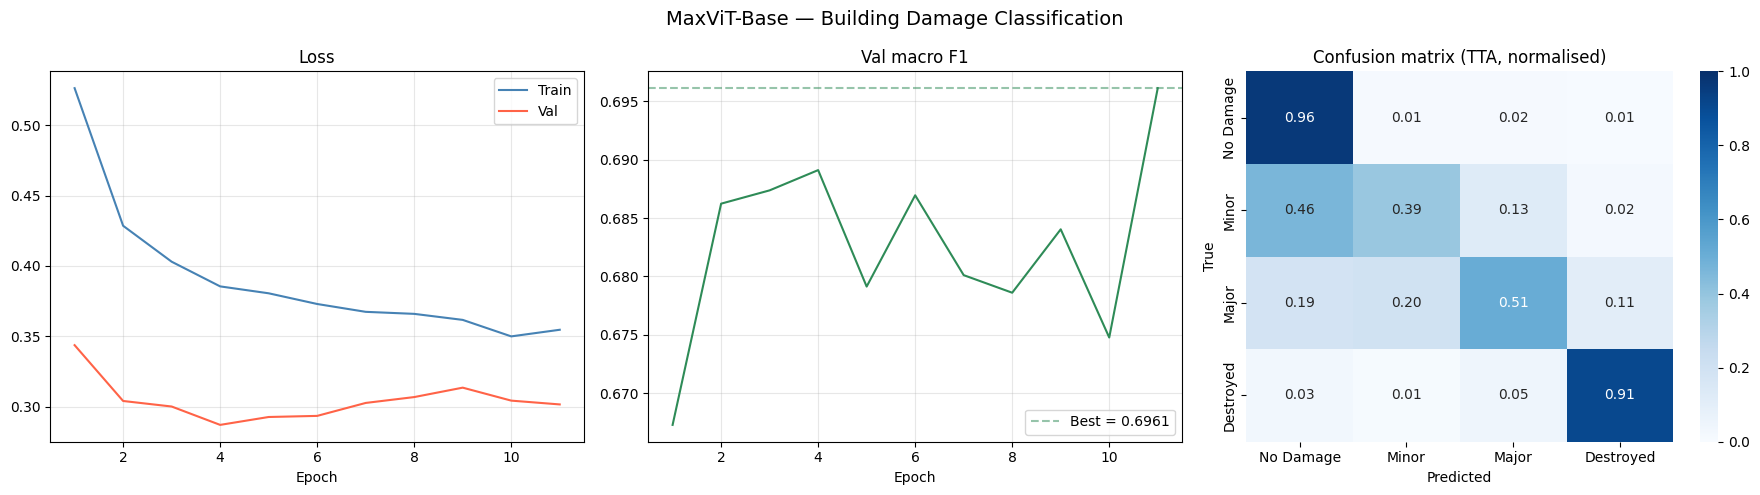

Saved to ../../Building_Damage_Project/Final_Merge/results_maxvit.png


In [13]:
# ── STEP 11: RESULTS PLOTS ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MaxViT-Base — Building Damage Classification', fontsize=14)

ep = range(1, len(history['train_loss']) + 1)

# Loss
ax = axes[0]
ax.plot(ep, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

# F1
ax = axes[1]
ax.plot(ep, history['val_f1'], color='seagreen')
ax.axhline(best_f1, ls='--', color='seagreen', alpha=0.5,
           label=f'Best = {best_f1:.4f}')
ax.set_title('Val macro F1')
ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

# Confusion matrix
ax  = axes[2]
cm  = confusion_matrix(tta_labels, tta_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.2f', ax=ax, cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1)
ax.set_title('Confusion matrix (TTA, normalised)')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(PLOT_SAVE, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {PLOT_SAVE}")

In [17]:
# ── STEP 12 (OPTIONAL): PSEUDO-LABELING ──────────────────────────────────────
# After getting a strong baseline, use high-confidence test predictions
# as extra training data. Repeat Steps 4-9 with the merged dataset.

PSEUDO_THRESHOLD = 0.95

max_probs     = tta_probs.max(axis=1)
confident_idx = np.where(max_probs >= PSEUDO_THRESHOLD)[0]
pseudo_labels = tta_preds[confident_idx]
pseudo_fnames = [test_fnames[i] for i in confident_idx]

print(f"High-confidence pseudo-labels: {len(confident_idx)} / {len(test_fnames)}"
      f" ({100*len(confident_idx)/len(test_fnames):.1f}%)")
print(f"Pseudo class dist: {dict(zip(CLASS_NAMES, np.bincount(pseudo_labels, minlength=4)))}")
print()
print("To activate pseudo-labeling:")
print("  augmented_train = train_fnames + pseudo_fnames")
print("  Then re-run Steps 4-9 with augmented_train as the training set.")

High-confidence pseudo-labels: 2 / 3926 (0.1%)
Pseudo class dist: {'No Damage': np.int64(0), 'Minor': np.int64(0), 'Major': np.int64(0), 'Destroyed': np.int64(2)}

To activate pseudo-labeling:
  augmented_train = train_fnames + pseudo_fnames
  Then re-run Steps 4-9 with augmented_train as the training set.
